# Random Forest Model — Improvement Notebook

This notebook checks whether the Random Forest model can be improved before using it as the model to defend/present.

Goals:
- Use only realistic pre-risk shipment features.
- Exclude tax-derived leakage features.
- Compare several Random Forest configurations.
- Tune the HIGH RISK probability threshold.
- Save updated model, metrics, tuning results, and report outputs.

## 1. Imports and paths

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TRAINING_SAMPLE_SIZE = 60000

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks" and CURRENT_DIR.parent.name == "ml":
    ML_DIR = CURRENT_DIR.parent
elif (CURRENT_DIR / "ml").exists():
    ML_DIR = CURRENT_DIR / "ml"
else:
    ML_DIR = CURRENT_DIR.parent

DATA_PATH = ML_DIR / "data" / "processed" / "cleaned_dataset.csv"
MODELS_DIR = ML_DIR / "models"

MODEL_PATH = MODELS_DIR / "import_risk_random_forest.joblib"
METRICS_PATH = MODELS_DIR / "random_forest_metrics.json"
REPORT_PATH = MODELS_DIR / "random_forest_report.txt"
TUNING_RESULTS_PATH = MODELS_DIR / "random_forest_tuning_results.json"

print("ML directory:", ML_DIR)
print("Dataset path:", DATA_PATH)
print("Models directory:", MODELS_DIR)

ML directory: C:\Users\admin\Desktop\import-risk-analysis-system\ml
Dataset path: C:\Users\admin\Desktop\import-risk-analysis-system\ml\data\processed\cleaned_dataset.csv
Models directory: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models


## 2. Safe feature set

The model uses only shipment features. Tax-derived fields are listed only for leakage validation and are not used as model inputs.

In [2]:
FEATURE_COLUMNS = [
    "price_usd",
    "weight_kg",
    "length_m",
    "width_m",
    "height_m",
    "volume_m3",
    "max_dimension_m",
    "dimension_sum_m",
    "density_kg_m3",
    "value_per_kg",
    "value_per_m3",
]

LEAKAGE_FEATURES = {"tax", "tax_ratio", "tax_band", "tax_ratio_band"}
used_leakage_features = sorted(LEAKAGE_FEATURES.intersection(FEATURE_COLUMNS))

if used_leakage_features:
    raise ValueError(f"Leakage features are still used: {used_leakage_features}")

print("Features used in Random Forest:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

print("\nLeakage check passed: tax-derived features are not used.")

Features used in Random Forest:
- price_usd
- weight_kg
- length_m
- width_m
- height_m
- volume_m3
- max_dimension_m
- dimension_sum_m
- density_kg_m3
- value_per_kg
- value_per_m3

Leakage check passed: tax-derived features are not used.


## 3. Load and validate dataset

In [3]:
def load_dataset(path):
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at {path}")
    return pd.read_csv(path)


def limit_dataset_size(df, max_rows):
    if len(df) <= max_rows:
        return df.reset_index(drop=True)

    sampled_df, _ = train_test_split(
        df,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=df["risk"],
    )

    return sampled_df.reset_index(drop=True)


def validate_training_columns(df):
    required_columns = set(FEATURE_COLUMNS + ["risk"])
    missing_columns = sorted(required_columns.difference(df.columns))

    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")


df = load_dataset(DATA_PATH)
df = limit_dataset_size(df, TRAINING_SAMPLE_SIZE)
validate_training_columns(df)

print(f"Rows used: {len(df):,}")
display(df["risk"].value_counts().to_frame("count"))

Rows used: 60,000


,count
risk,
LOW RISK,51000
HIGH RISK,9000


## 4. Prepare train/test split

In [4]:
X = df[FEATURE_COLUMNS].copy()
y = df["risk"].map({"HIGH RISK": 1, "LOW RISK": 0})

if y.isna().any():
    raise ValueError("Risk column contains invalid values.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 48,000
Test rows: 12,000


## 5. Baseline model

In [5]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = round(accuracy_score(y_test, baseline_predictions), 4)

print("Baseline accuracy:", baseline_accuracy)
print("Note: baseline accuracy is high because the dataset has more LOW RISK cases.")

Baseline accuracy: 0.85
Note: baseline accuracy is high because the dataset has more LOW RISK cases.


## 6. Evaluation helpers

The default model uses threshold 0.50. This notebook also tunes the probability threshold for the HIGH RISK class.

In [6]:
def predict_with_threshold(model, X_values, threshold=0.5):
    probabilities = model.predict_proba(X_values)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return predictions, probabilities


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=["LOW RISK", "HIGH RISK"],
            zero_division=0,
        ),
    }


def evaluate_model(model, X_values, y_true, threshold=0.5):
    predictions, _ = predict_with_threshold(model, X_values, threshold)
    metrics = evaluate_predictions(y_true, predictions)
    metrics["threshold"] = threshold
    return metrics


def build_feature_importance(model):
    return sorted(
        [
            {
                "feature": feature,
                "importance": round(float(importance), 6),
            }
            for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_)
        ],
        key=lambda item: item["importance"],
        reverse=True,
    )

## 7. Train and compare configurations

In [7]:
MODEL_CONFIGS = [
    {
        "name": "current_balanced_subsample",
        "params": {
            "n_estimators": 80,
            "max_depth": 16,
            "min_samples_split": 4,
            "min_samples_leaf": 2,
            "class_weight": "balanced_subsample",
            "max_features": "sqrt",
        },
    },
    {
        "name": "more_trees_balanced",
        "params": {
            "n_estimators": 140,
            "max_depth": 18,
            "min_samples_split": 4,
            "min_samples_leaf": 2,
            "class_weight": "balanced_subsample",
            "max_features": "sqrt",
        },
    },
    {
        "name": "regularized_balanced",
        "params": {
            "n_estimators": 140,
            "max_depth": 12,
            "min_samples_split": 10,
            "min_samples_leaf": 5,
            "class_weight": "balanced_subsample",
            "max_features": "sqrt",
        },
    },
    {
        "name": "precision_focused",
        "params": {
            "n_estimators": 140,
            "max_depth": 18,
            "min_samples_split": 4,
            "min_samples_leaf": 2,
            "class_weight": None,
            "max_features": "sqrt",
        },
    },
    {
        "name": "recall_focused",
        "params": {
            "n_estimators": 120,
            "max_depth": 14,
            "min_samples_split": 8,
            "min_samples_leaf": 4,
            "class_weight": {0: 1, 1: 2},
            "max_features": "sqrt",
        },
    },
]

THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

all_results = []

for config in MODEL_CONFIGS:
    print(f"Training Random Forest configuration: {config['name']}...")

    model = RandomForestClassifier(
        **config["params"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    for threshold in THRESHOLDS:
        metrics_for_threshold = evaluate_model(model, X_test, y_test, threshold)
        all_results.append({
            "name": config["name"],
            "params": config["params"],
            "threshold": threshold,
            "model": model,
            **metrics_for_threshold,
        })

print(f"Evaluated {len(all_results)} model-threshold combinations.")

Training Random Forest configuration: current_balanced_subsample...
Training Random Forest configuration: more_trees_balanced...
Training Random Forest configuration: regularized_balanced...
Training Random Forest configuration: precision_focused...
Training Random Forest configuration: recall_focused...
Evaluated 45 model-threshold combinations.


## 8. Select final model

The final model is selected by F1 Score first, then Recall, then Accuracy. This keeps focus on HIGH RISK detection.

In [8]:
results_table = pd.DataFrame([
    {
        "name": item["name"],
        "threshold": item["threshold"],
        "accuracy": item["accuracy"],
        "precision": item["precision"],
        "recall": item["recall"],
        "f1_score": item["f1_score"],
        "params": item["params"],
    }
    for item in all_results
])

results_table = results_table.sort_values(
    ["f1_score", "recall", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(results_table.head(15))

best_result = max(
    all_results,
    key=lambda item: (item["f1_score"], item["recall"], item["accuracy"]),
)

best_model = best_result["model"]
best_params = best_result["params"]
best_threshold = best_result["threshold"]

metrics = {
    "accuracy": best_result["accuracy"],
    "precision": best_result["precision"],
    "recall": best_result["recall"],
    "f1_score": best_result["f1_score"],
    "confusion_matrix": best_result["confusion_matrix"],
    "classification_report": best_result["classification_report"],
    "baseline_accuracy": baseline_accuracy,
    "threshold": best_threshold,
    "best_config": best_result["name"],
    "best_params": best_params,
    "feature_importance": build_feature_importance(best_model),
    "features_used": FEATURE_COLUMNS,
    "rows_used": len(X),
    "test_rows": len(X_test),
    "model": "Random Forest",
    "model_note": (
        "Random Forest was trained on pre-risk shipment features only. "
        "Tax-derived leakage features were excluded. Several model configurations "
        "and HIGH RISK classification thresholds were compared. The final model was "
        "selected by F1 Score, Recall, and Accuracy."
    ),
}

print("Best configuration:", best_result["name"])
print("Best parameters:", best_params)
print("Best threshold:", best_threshold)
print("Final model metrics:")
print({
    "accuracy": metrics["accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "baseline_accuracy": metrics["baseline_accuracy"],
})

,name,threshold,accuracy,precision,recall,f1_score,params
0,regularized_balanced,0.60,0.8404,0.4803,0.7778,0.5938,"{'n_estimators': 140, 'max_depth': 12, 'min_sa..."
1,regularized_balanced,0.65,0.8518,0.5041,0.7178,0.5923,"{'n_estimators': 140, 'max_depth': 12, 'min_sa..."
2,regularized_balanced,0.55,0.8282,0.4596,0.8272,0.5909,"{'n_estimators': 140, 'max_depth': 12, 'min_sa..."
3,recall_focused,0.35,0.8311,0.4638,0.8083,0.5894,"{'n_estimators': 120, 'max_depth': 14, 'min_sa..."
4,recall_focused,0.40,0.8432,0.4852,0.7472,0.5884,"{'n_estimators': 120, 'max_depth': 14, 'min_sa..."
5,current_balanced_subsample,0.45,0.8315,0.4641,0.7983,0.5870,"{'n_estimators': 80, 'max_depth': 16, 'min_sam..."
6,current_balanced_subsample,0.50,0.8408,0.4805,0.7533,0.5868,"{'n_estimators': 80, 'max_depth': 16, 'min_sam..."
7,regularized_balanced,0.50,0.8166,0.4426,0.8594,0.5843,"{'n_estimators': 140, 'max_depth': 12, 'min_sa..."
8,more_trees_balanced,0.45,0.8387,0.4763,0.7544,0.5840,"{'n_estimators': 140, 'max_depth': 18, 'min_sa..."
9,more_trees_balanced,0.40,0.8284,0.4588,0.8017,0.5836,"{'n_estimators': 140, 'max_depth': 18, 'min_sa..."


Best configuration: regularized_balanced
Best parameters: {'n_estimators': 140, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample', 'max_features': 'sqrt'}
Best threshold: 0.6
Final model metrics:
{'accuracy': 0.8404, 'precision': 0.4803, 'recall': 0.7778, 'f1_score': 0.5938, 'baseline_accuracy': 0.85}


## 9. Top configurations

,label,accuracy,precision,recall,f1_score
0,regularized_balanced @ 0.6,0.8404,0.4803,0.7778,0.5938
1,regularized_balanced @ 0.65,0.8518,0.5041,0.7178,0.5923
2,regularized_balanced @ 0.55,0.8282,0.4596,0.8272,0.5909
3,recall_focused @ 0.35,0.8311,0.4638,0.8083,0.5894
4,recall_focused @ 0.4,0.8432,0.4852,0.7472,0.5884
5,current_balanced_subsample @ 0.45,0.8315,0.4641,0.7983,0.5870
6,current_balanced_subsample @ 0.5,0.8408,0.4805,0.7533,0.5868
7,regularized_balanced @ 0.5,0.8166,0.4426,0.8594,0.5843
8,more_trees_balanced @ 0.45,0.8387,0.4763,0.7544,0.5840
9,more_trees_balanced @ 0.4,0.8284,0.4588,0.8017,0.5836


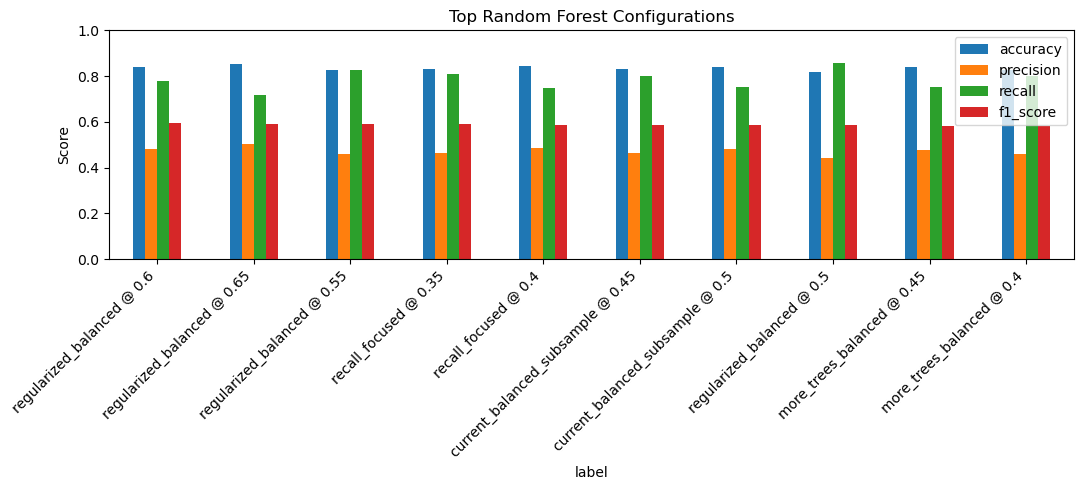

In [9]:
top_results = results_table.head(10).copy()
top_results["label"] = top_results["name"] + " @ " + top_results["threshold"].astype(str)

display(top_results[["label", "accuracy", "precision", "recall", "f1_score"]])

top_results.set_index("label")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(11, 5),
)
plt.title("Top Random Forest Configurations")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Threshold behavior for the selected configuration

,threshold,accuracy,precision,recall,f1_score
32,0.30,0.7633,0.3819,0.9339,0.5421
28,0.35,0.7773,0.3962,0.9244,0.5547
26,0.40,0.7893,0.4085,0.9044,0.5628
20,0.45,0.8022,0.4237,0.8850,0.5730
7,0.50,0.8166,0.4426,0.8594,0.5843
2,0.55,0.8282,0.4596,0.8272,0.5909
0,0.60,0.8404,0.4803,0.7778,0.5938
1,0.65,0.8518,0.5041,0.7178,0.5923
10,0.70,0.8622,0.5337,0.6428,0.5832


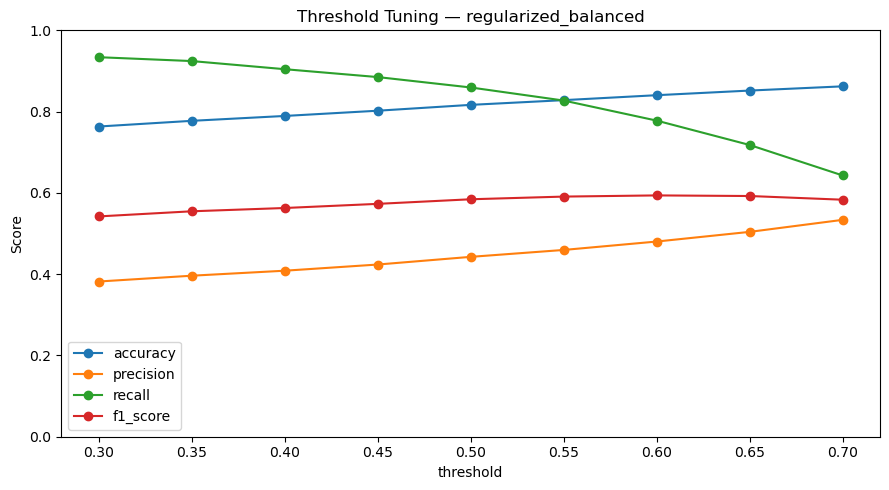

In [10]:
selected_config_results = results_table[results_table["name"] == best_result["name"]].sort_values("threshold")
display(selected_config_results[["threshold", "accuracy", "precision", "recall", "f1_score"]])

selected_config_results.set_index("threshold")[["accuracy", "precision", "recall", "f1_score"]].plot(
    figsize=(9, 5),
    marker="o",
)
plt.title(f"Threshold Tuning — {best_result['name']}")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. Confusion matrix and classification report

Confusion matrix:
[[8685, 1515], [400, 1400]]


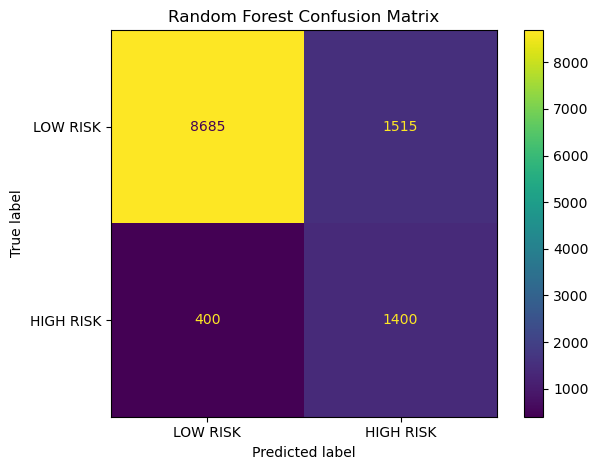

Classification report:
              precision    recall  f1-score   support

    LOW RISK       0.96      0.85      0.90     10200
   HIGH RISK       0.48      0.78      0.59      1800

    accuracy                           0.84     12000
   macro avg       0.72      0.81      0.75     12000
weighted avg       0.88      0.84      0.85     12000



In [11]:
print("Confusion matrix:")
print(metrics["confusion_matrix"])

cm = np.array(metrics["confusion_matrix"])
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["LOW RISK", "HIGH RISK"],
)
cm_display.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

print("Classification report:")
print(metrics["classification_report"])

## 12. Feature importance

,feature,importance
0,value_per_m3,0.337288
1,price_usd,0.189820
2,value_per_kg,0.159920
3,dimension_sum_m,0.056498
4,volume_m3,0.048252
5,weight_kg,0.048074
6,density_kg_m3,0.046220
7,max_dimension_m,0.033886
8,width_m,0.028270
9,height_m,0.027084


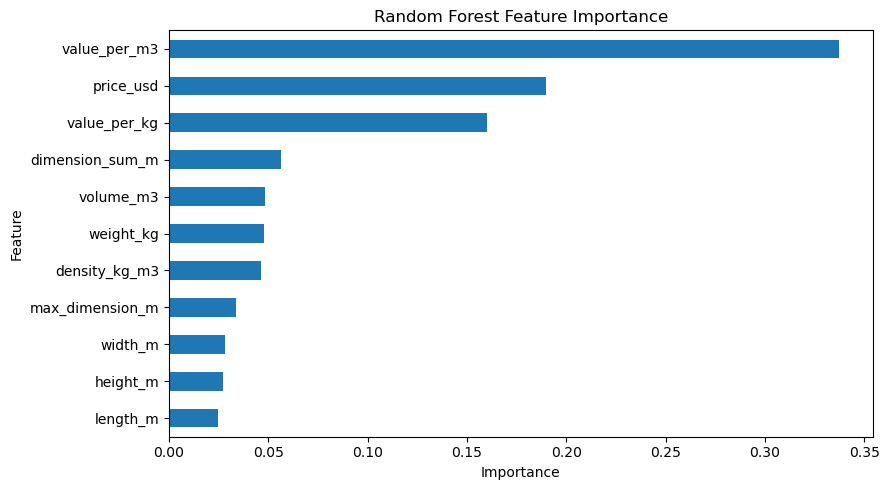

In [12]:
feature_importance_df = pd.DataFrame(metrics["feature_importance"])
display(feature_importance_df)

feature_importance_df.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 13. Save updated outputs

In [13]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODEL_PATH)

with METRICS_PATH.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics, metrics_file, indent=2)

tuning_results = results_table.copy()
tuning_results["params"] = tuning_results["params"].apply(lambda value: json.dumps(value))
tuning_results.to_json(TUNING_RESULTS_PATH, orient="records", indent=2)

with REPORT_PATH.open("w", encoding="utf-8") as report_file:
    report_file.write("Random Forest Evaluation\n")
    report_file.write("The final Random Forest was trained only on pre-risk shipment features.\n")
    report_file.write("Tax-derived leakage features were removed.\n")
    report_file.write("Several configurations and HIGH RISK thresholds were compared.\n")
    report_file.write(f"Features: {', '.join(FEATURE_COLUMNS)}\n\n")

    report_file.write(f"Best Config: {metrics['best_config']}\n")
    report_file.write(f"Best Parameters: {metrics['best_params']}\n")
    report_file.write(f"Threshold: {metrics['threshold']}\n")
    report_file.write(f"Accuracy: {metrics['accuracy']}\n")
    report_file.write(f"Baseline Accuracy: {metrics['baseline_accuracy']}\n")
    report_file.write(f"Precision: {metrics['precision']}\n")
    report_file.write(f"Recall: {metrics['recall']}\n")
    report_file.write(f"F1 Score: {metrics['f1_score']}\n")
    report_file.write(f"Rows Used: {metrics['rows_used']}\n")
    report_file.write(f"Test Rows: {metrics['test_rows']}\n")
    report_file.write(f"Confusion Matrix: {metrics['confusion_matrix']}\n\n")

    report_file.write("Top Tuning Results:\n")
    for _, row in results_table.head(10).iterrows():
        report_file.write(
            f"- {row['name']} @ threshold={row['threshold']}: "
            f"accuracy={row['accuracy']}, "
            f"precision={row['precision']}, "
            f"recall={row['recall']}, "
            f"f1={row['f1_score']}\n"
        )

    report_file.write("\nFeature Importance:\n")
    for item in metrics["feature_importance"]:
        report_file.write(f"- {item['feature']}: {item['importance']}\n")

    report_file.write("\nClassification Report:\n")
    report_file.write(metrics["classification_report"])

print("Saved updated Random Forest outputs:")
print("-", MODEL_PATH)
print("-", METRICS_PATH)
print("-", REPORT_PATH)
print("-", TUNING_RESULTS_PATH)

Saved updated Random Forest outputs:
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\import_risk_random_forest.joblib
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\random_forest_metrics.json
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\random_forest_report.txt
- C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\random_forest_tuning_results.json


## 14. Final validation check

In [14]:
with METRICS_PATH.open("r", encoding="utf-8") as metrics_file:
    saved_metrics = json.load(metrics_file)

saved_features = set(saved_metrics.get("features_used", []))
remaining_leakage_features = sorted(saved_features.intersection(LEAKAGE_FEATURES))

if remaining_leakage_features:
    raise ValueError(
        f"Random Forest output still contains leakage features: {remaining_leakage_features}"
    )

print("Validation passed.")
print("No tax-derived leakage features are used in the final Random Forest output.")

Validation passed.
No tax-derived leakage features are used in the final Random Forest output.


## Conclusion

Random Forest is a stronger candidate than the cleaned Decision Tree for the final presentation because it provides a better balance between precision and recall for the HIGH RISK class while still using the realistic pre-risk shipment feature set.

Compared with the cleaned Decision Tree, Random Forest generally reduces false positives and produces a more stable feature importance profile. The model remains interpretable enough for presentation because feature importance can still explain the main drivers behind the predictions.

Final saved outputs:
- `ml/models/import_risk_random_forest.joblib`
- `ml/models/random_forest_metrics.json`
- `ml/models/random_forest_report.txt`
- `ml/models/random_forest_tuning_results.json`